# IGT Simulation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
from ipywidgets import interact, IntSlider, FloatSlider
from modules.IGT_Simulation import create_pulse_train, generate_single_out_current, current_to_voltage

%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
TIME_RESOLUTION = 0.01

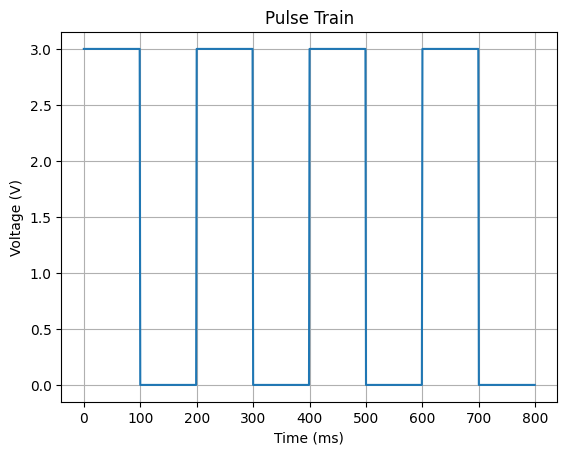

In [3]:
pulse_train = np.repeat(create_pulse_train(
    basic_voltage = 0,
    pulse_voltage = 3,
    pulse_duration = 10,
    interval_duration = 10, 
    pulse_quantity = 4
), TIME_RESOLUTION * 1000)

time = range(len(pulse_train))

plt.plot(time, pulse_train)
plt.title("Pulse Train")
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (V)")
plt.grid()
plt.show()

In [4]:
BETA = 0.76
TAU = 9/1000
K = 700

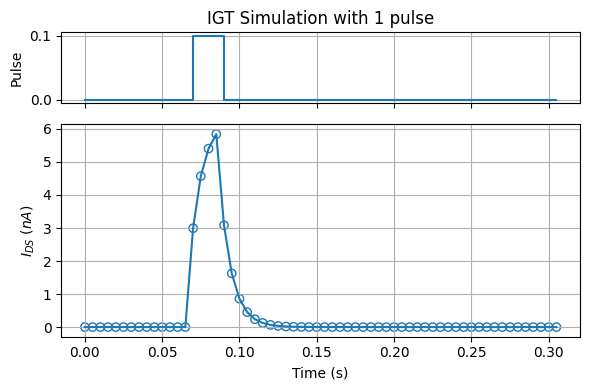

In [5]:
TIME_RESOLUTION = 0.005

pulse_train = np.concatenate((
    np.zeros(14),
    create_pulse_train(0, 0.1, 4, 0, 1),
    np.zeros(44)
))

out_current = generate_single_out_current(pulse_train, K, BETA, TAU, TIME_RESOLUTION, True, "IGT Simulation with 1 pulse")

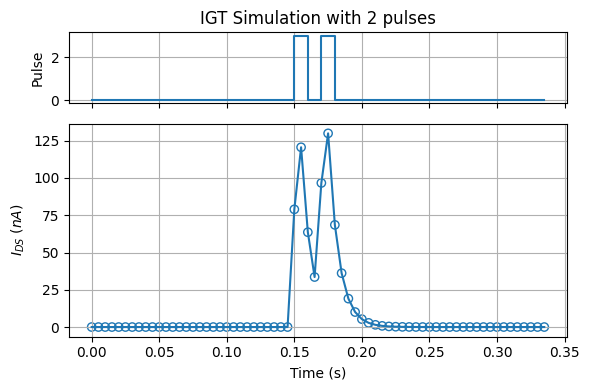

In [6]:
TIME_RESOLUTION = 0.005

pulse_train = np.concatenate((
    np.zeros(30),
    create_pulse_train(0, 3, 2, 2, 2),
    np.zeros(30)
))

out_current = generate_single_out_current(pulse_train, K, BETA, TAU, TIME_RESOLUTION, True, title="IGT Simulation with 2 pulses")
plt.show()

In [7]:
BETA = 0.56
TAU = 2.6
K = 700

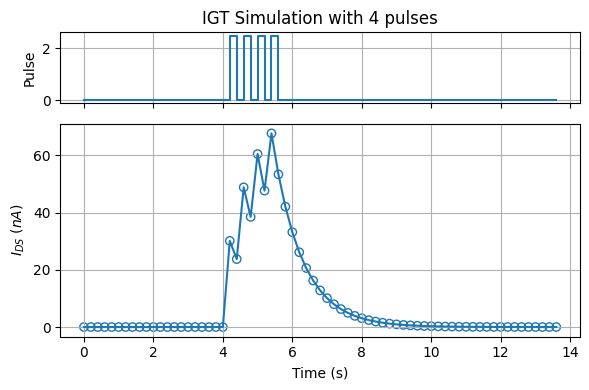

In [8]:
TIME_RESOLUTION = 0.2

pulse_train = np.concatenate((
    np.zeros(1),
    np.zeros(20),
    create_pulse_train(0, 2.5, 1, 1, 4),
    np.zeros(40)
))

out_current = generate_single_out_current(pulse_train, K, BETA, TAU, TIME_RESOLUTION, True, "IGT Simulation with 4 pulses")

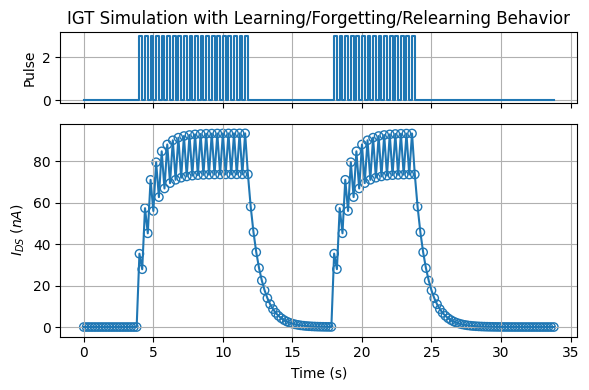

In [9]:
TIME_RESOLUTION = 0.2

pulse_train = np.concatenate((
    np.zeros(20),
    create_pulse_train(0, 3, 1, 1, 20),
    np.zeros(30),
    create_pulse_train(0, 3, 1, 1, 15),
    np.zeros(50)
))

out_current = generate_single_out_current(pulse_train, K, BETA, TAU, TIME_RESOLUTION, True, "IGT Simulation with Learning/Forgetting/Relearning Behavior")

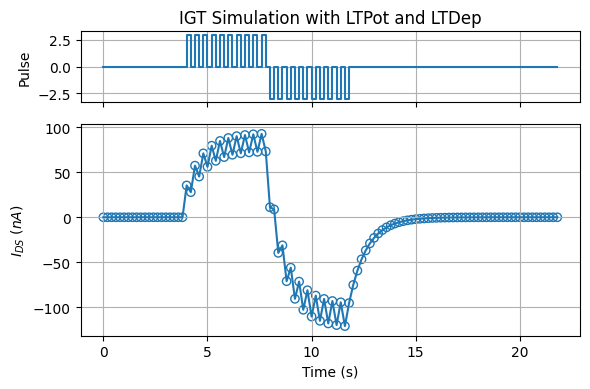

In [10]:
TIME_RESOLUTION = 0.2

pulse_train = np.concatenate((
    np.zeros(20),
    create_pulse_train(0, 3, 1, 1, 10),
    create_pulse_train(0, -3, 1, 1, 10),
    np.zeros(50)
))

out_current = generate_single_out_current(pulse_train, K, BETA, TAU, TIME_RESOLUTION, True, "IGT Simulation with LTPot and LTDep")

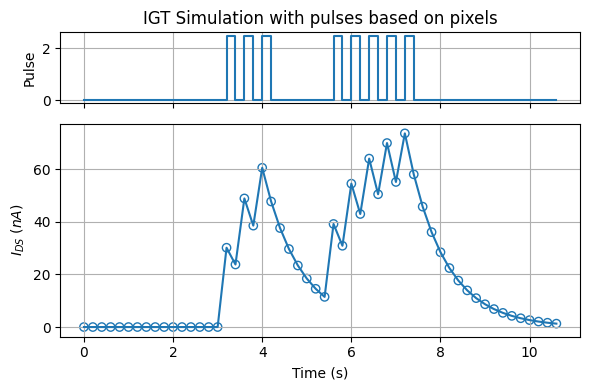

In [11]:
TIME_RESOLUTION = 0.2

pulse_train = np.concatenate((
    np.zeros(8*2),
    create_pulse_train(0, 2.5, 1, 1, 3),
    np.zeros(3*2),
    create_pulse_train(0, 2.5, 1, 1, 5),
    np.zeros(8*2)
))

out_current = generate_single_out_current(pulse_train, K, BETA, TAU, TIME_RESOLUTION, True, "IGT Simulation with pulses based on pixels")

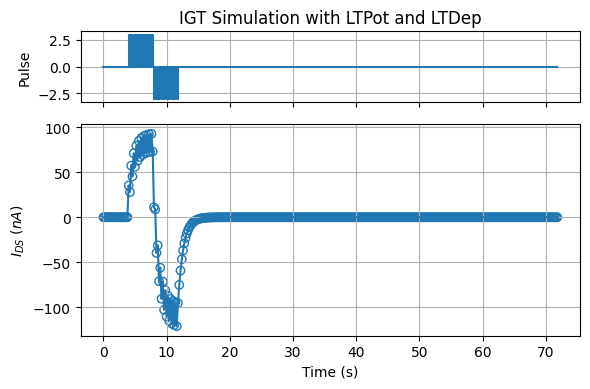

interactive(children=(IntSlider(value=0, description='qtd'), Output()), _dom_classes=('widget-interact',))

<function __main__.update_plots(qtd)>

In [12]:
TIME_RESOLUTION = 0.2

pulse_train = np.concatenate((
    np.zeros(20),
    create_pulse_train(0, 3, 1, 1, 10),
    create_pulse_train(0, -3, 1, 1, 10),
    np.zeros(300)
))

initial_current = generate_single_out_current(pulse_train, K, BETA, TAU, TIME_RESOLUTION, True, "IGT Simulation with LTPot and LTDep")

def update_plots(qtd):
    clear_output(wait=True)
    plt.close("all")

    out_current = initial_current.copy()

    for _ in range(qtd):
        out_current = generate_single_out_current(current_to_voltage(out_current, K), K, BETA, TAU, TIME_RESOLUTION)

    out_current = generate_single_out_current(current_to_voltage(out_current, K), K, BETA, TAU, TIME_RESOLUTION, True, f"IGT Simulation after {qtd+1} iterations", ((0,70), (-120,120)))

interact(
    update_plots,
    qtd = IntSlider(value=0, min=0, max=100)
)


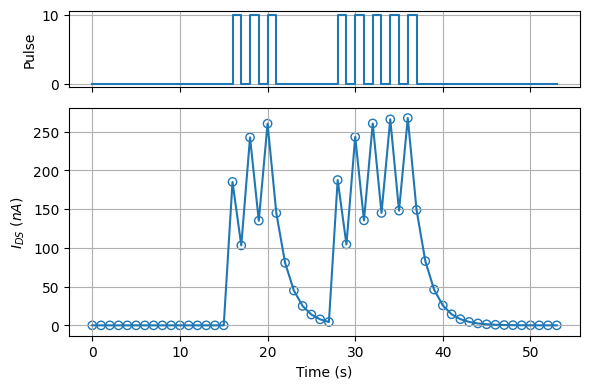

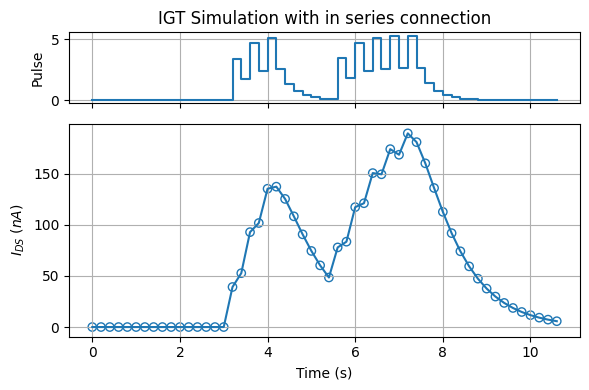

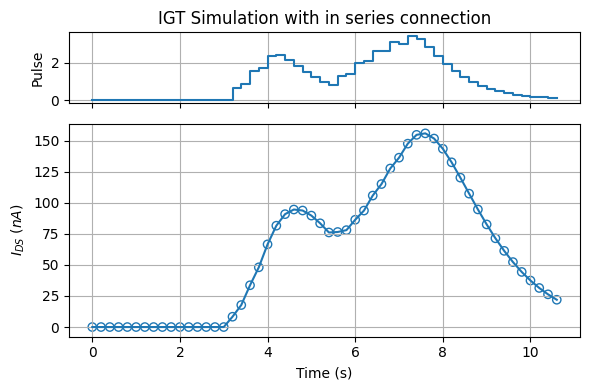

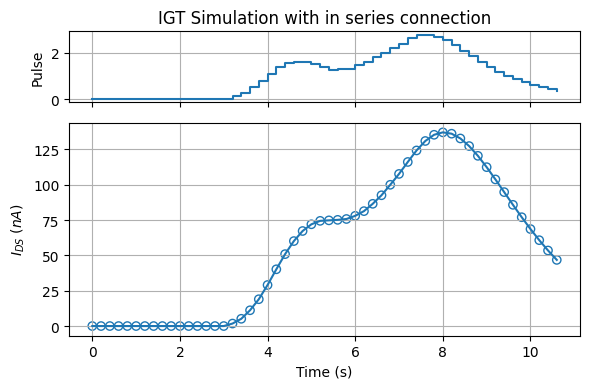

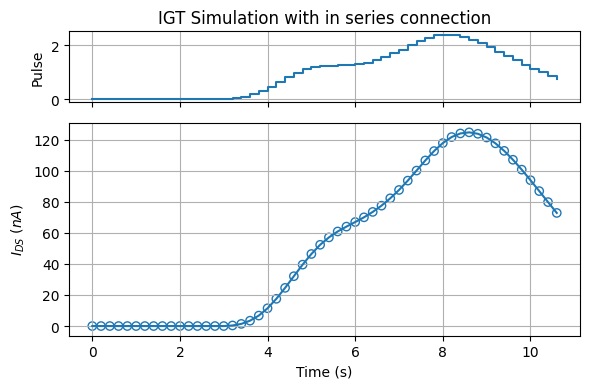

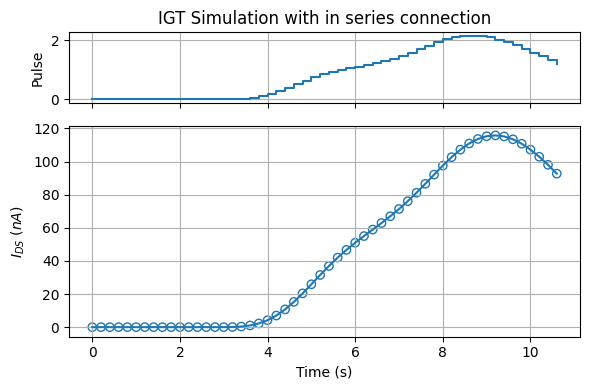

In [13]:
TIME_RESOLUTION = 0.2

pulse_train = np.concatenate((
    np.zeros(8*2),
    create_pulse_train(0, 10, 1, 1, 3),
    np.zeros(3*2),
    create_pulse_train(0, 10, 1, 1, 5),
    np.zeros(8*2)
))

out_current = generate_single_out_current(pulse_train, K, BETA, TAU, True, "IGT Simulation with pulses based on pixels")
for i in range(5):
    out_current = generate_single_out_current(current_to_voltage(out_current, K), K, BETA, TAU, TIME_RESOLUTION, True, "IGT Simulation with in series connection")

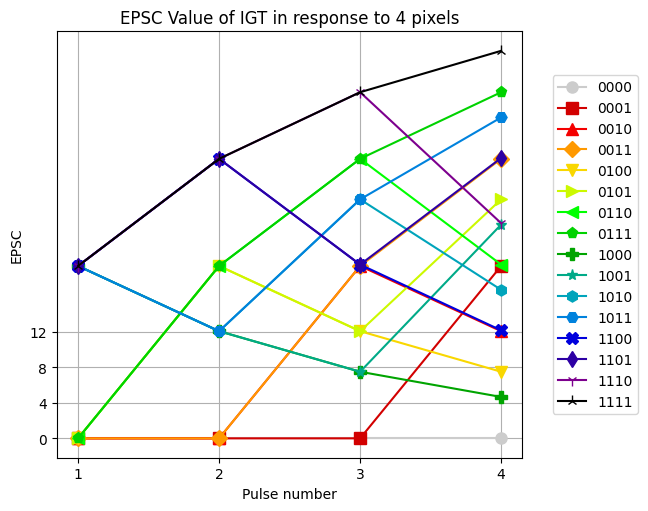

In [14]:
# K = 400
# BETA = 0.65
# TAU = 3.00

markers = ["o","s","^","D","v",">","<","p","P","*","h","H","X","d","1","2"]
colors = plt.cm.nipy_spectral_r(np.linspace(0, 1, 16))

for i in range(16):
    pulse_train = np.array(list(str(format(i, "04b"))), dtype=np.uint8) * 2.5

    zeros = np.zeros(8, dtype=np.uint)
    zeros[::2] = pulse_train
    pulse_train = zeros
    pulse_train = np.concatenate((np.zeros(4), pulse_train))

    out_current = generate_single_out_current(pulse_train, K, BETA, TAU, TIME_RESOLUTION)
    # print(out_current)
    true_out_current = out_current[5::2]

    plt.plot(range(1,1+len(true_out_current)), true_out_current, label=format(i, "04b"), color=colors[i], marker=markers[i], markersize=8)

plt.grid()
plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left")
plt.tight_layout()
plt.title("EPSC Value of IGT in response to 4 pixels")
plt.xlabel("Pulse number")
plt.ylabel("EPSC")
plt.xticks(range(1,5))
plt.yticks([0, 4, 8, 12])
plt.show()

In [15]:
K = 400
BETA = 0.65
TAU = 3.00

K = 700
BETA = 0.57
TAU = 2.6

markers = ["o","s","^","D","v",">","<","p","P","*","h","H","X","d","1","2"]
colors = plt.cm.nipy_spectral_r(np.linspace(0, 1, 16))
signals = [0, 8, 12, 2, 11, 6, 14, 1, 9, 5, 13, 3, 11, 7, 15]

def update_plot(k, beta, tau, voltage):

    for i, signal in enumerate(signals):
        pulse_train = np.array(list(str(format(signal, "04b"))), dtype=np.uint8) * voltage

        zeros = np.zeros(8, dtype=np.uint)
        zeros[::2] = pulse_train
        pulse_train = zeros
        pulse_train = np.concatenate((np.zeros(4), pulse_train))

        out_current = generate_single_out_current(pulse_train, k, beta, tau, TIME_RESOLUTION)
        # print(out_current)
        true_out_current = out_current[5::]

        plt.plot(range(1,1+len(true_out_current)), true_out_current, label=format(signal, "04b")+" "+str(signal), color=colors[i], marker=markers[i], markersize=8)

    plt.grid()
    plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left")
    plt.tight_layout()
    plt.title("EPSC Value of IGT in response to 4 pixels")
    plt.xlabel("Pulse number")
    plt.ylabel("EPSC")
    plt.xticks(range(1,5))
    plt.show()

interact(
    update_plot,
    k = IntSlider(value=K, min=0, max=1000, step=1),
    beta = FloatSlider(value=0.09, min=0, max=1, step=0.01),
    tau = FloatSlider(value=20000, min=0, max=200000, step=0.1),
    voltage = FloatSlider(value=1, min=0, max=10, step=0.1)
)

interactive(children=(IntSlider(value=700, description='k', max=1000), FloatSlider(value=0.09, description='be…

<function __main__.update_plot(k, beta, tau, voltage)>

## References

[1] Zhu, L., Wan, X., Lin, J., Chen, P., Luo, Z., Sun, H., Yan, S., Tan, C. L., Yu, Z., & Xu, Y. (2025). *Reservoir computing for image processing based on ion-gated flexible organic transistors with nonlinear synaptic dynamics*. **Organic Electronics, 139**, 107199. https://doi.org/10.1016/j.orgel.2025.107199

[2] Chang Jin Wan, Li Qiang Zhu, Xiang Wan, Yi Shi, Qing Wan; *Organic/inorganic hybrid synaptic transistors gated by proton conducting methylcellulose films*. **Appl. Phys. Lett. 25 January 2016; 108 (4)**: 043508. https://doi.org/10.1063/1.4941080